In [1]:
import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = ChatGroq(model="qwen/qwen3-32b")

### Make Tavily Tool

In [4]:
from langchain_tavily import TavilySearch 

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general"
)
tavily_search_tool.invoke("What is the current AI News ?")

{'query': 'What is the current AI News ?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': "OpenAI opens Singapore AI lab as IMDA updates AI framework · China's AI just mapped its entire renewable energy grid. · Musk and Zuckerberg convinced Trump to",
   'score': 0.6530611,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology.',
   'score': 0.62330866,
   'raw_content': None},
  {'url': 'https://www.reuters.com/technology/artificial-intelligence',
   'title': 'AI News | Latest Headlines and Developments | Reuters',
   'content': 'Explore the latest artificial intelligence news with 

In [8]:
tool

TavilySearch(max_results=5, topic='general', api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

Here, we used the Tavily to search in the Google and the Ai News.

#### Making another tool i.e. Calculator tool

In [10]:
from langchain.tools import tool

@tool("calculator", description="Performs arithmetic calculations. Use this for any math problem.")
def calc(expression:str)->str:
    """
    Evaluate mathematics expressions.
    """
    return str(eval(expression))

Let's create agent now:

In [11]:
from langchain.agents import create_agent 
agent=create_agent(
    model = model,
    tools = [tavily_search_tool, calc]
)

In [12]:
# we can also create an agent without using arguments:
agent=create_agent(model,[tavily_search_tool,calc])

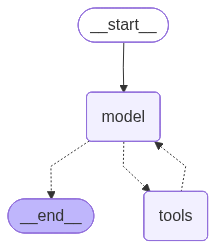

In [13]:
agent

Now we are having two tools. Let's see the execution

In [15]:
user_input = "What is the current AI News for Anthropic and then calculate 5 + 5" 

for step in agent.stream(
    {"messages": user_input},
    stream_mode = "values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI News for Anthropic and then calculate 5 + 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h8kmshk19)
 Call ID: h8kmshk19
  Args:
    query: AI News for Anthropic
    time_range: day
    topic: news
  calculator (24tjzqqcn)
 Call ID: 24tjzqqcn
  Args:
    expression: 5 + 5
================================= Tool Message =================================
Name: calculator

10
================================== Ai Message ==================================

Here's the latest AI news related to Anthropic and the calculation result:

**Anthropic AI News (Past 24 Hours):**
1. **Google Invests $40B in Anthropic's AI** - Major partnership announced for advanced AI development (YouTube video analysis)
2. **Mythos AI Security Concerns** - Unauthorized access reported to Anthropic's new model (Bloomberg investigation)
3. **Governmen

In [21]:
response=agent.invoke({"messages":"What is the current AI news"})
response

{'messages': [HumanMessage(content='What is the current AI news', additional_kwargs={}, response_metadata={}, id='d32f5652-2696-4a17-bea0-8a50743601f6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current AI news. Let me see which tool I should use here. The available tools are tavily_search and calculator. Since the user is asking for news, the calculator isn\'t going to help here. So I need to use tavily_search.\n\nNow, looking at the parameters for tavily_search. The query parameter is required, so I\'ll set that to "current AI news". The topic parameter can be set to "news" because the user is asking for the latest updates. The time_range should probably be "week" to get the most recent articles from the past week. I don\'t think the user wants anything older than that. \n\nWait, the time_range options are day, week, month, year. The user said "current", which might mean the latest, so maybe "day" would be better. But sometimes

In [20]:
response = agent.invoke({"messages":"What is the current AI news"})
response['messages'][-1].content

"Here are the latest AI news updates from reputable sources:\n\n1. **Reuters**  \n   [AI News | Latest Headlines and Developments](https://www.reuters.com/technology/artificial-intelligence)  \n   Covers breakthroughs, technology trends, regulation, and ethics in AI.\n\n2. **Artificial Intelligence News**  \n   [AI News | Insights Powering AI-Driven Business Growth](https://www.artificialintelligence-news.com)  \n   - OpenAI opens a Singapore AI lab as IMDA updates its AI framework.  \n   - China maps its entire renewable energy grid using AI.  \n   - Musk and Zuckerberg influence Trump on AI-related policies.\n\n3. **Wall Street Journal (WSJ)**  \n   [AI News and Analysis](https://www.wsj.com/tech/ai)  \n   Focuses on AI technology, tools, and companies driving innovation.\n\n4. **TechCrunch**  \n   [AI News & Artificial Intelligence](https://techcrunch.com/category/artificial-intelligence)  \n   - Ferrari uses IBM's AI to enhance F1 fan experiences.  \n   - Elon Musk shifts focus awa